# Backend analyze endpoint check

Notebook for manual testing of FastAPI endpoint `/analyze`.
It verifies API health, sends an image, decodes base64 response, previews result, and measures latency.

In [1]:
%pip install -q requests matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
import base64
import io
import time
from pathlib import Path

import matplotlib.pyplot as plt
import requests
from PIL import Image

BASE_URL = "http://localhost:8001"
HEALTH_URL = f"{BASE_URL}/health"
ANALYZE_URL = f"{BASE_URL}/analyze"

IMAGE_PATH = Path("test.webp")
TIMEOUT_SEC = 180

print(f"BASE_URL: {BASE_URL}")
print(f"IMAGE_PATH exists: {IMAGE_PATH.exists()}")

BASE_URL: http://localhost:8001
IMAGE_PATH exists: True


In [6]:
resp = requests.get(HEALTH_URL, timeout=15)
print("status:", resp.status_code)
print("body:", resp.text)
resp.raise_for_status()

status: 200
body: {"status":"ok"}


In [7]:
def call_analyze(image_path: Path, timeout_sec: int = TIMEOUT_SEC):
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path.resolve()}")

    started = time.time()
    with image_path.open("rb") as f:
        files = {"image": (image_path.name, f, "image/jpeg")}
        response = requests.post(ANALYZE_URL, files=files, timeout=timeout_sec)

    elapsed = time.time() - started
    print(f"HTTP: {response.status_code} | elapsed: {elapsed:.3f}s")

    try:
        payload = response.json()
    except ValueError as exc:
        raise RuntimeError(f"Non-JSON response: {response.text[:400]}") from exc

    if not payload.get("success"):
        return None, payload, elapsed

    if "image" not in payload:
        raise KeyError("Missing 'image' field in successful response")

    img_bytes = base64.b64decode(payload["image"])
    out_img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    return out_img, payload, elapsed

HTTP: 200 | elapsed: 3.350s
success: True


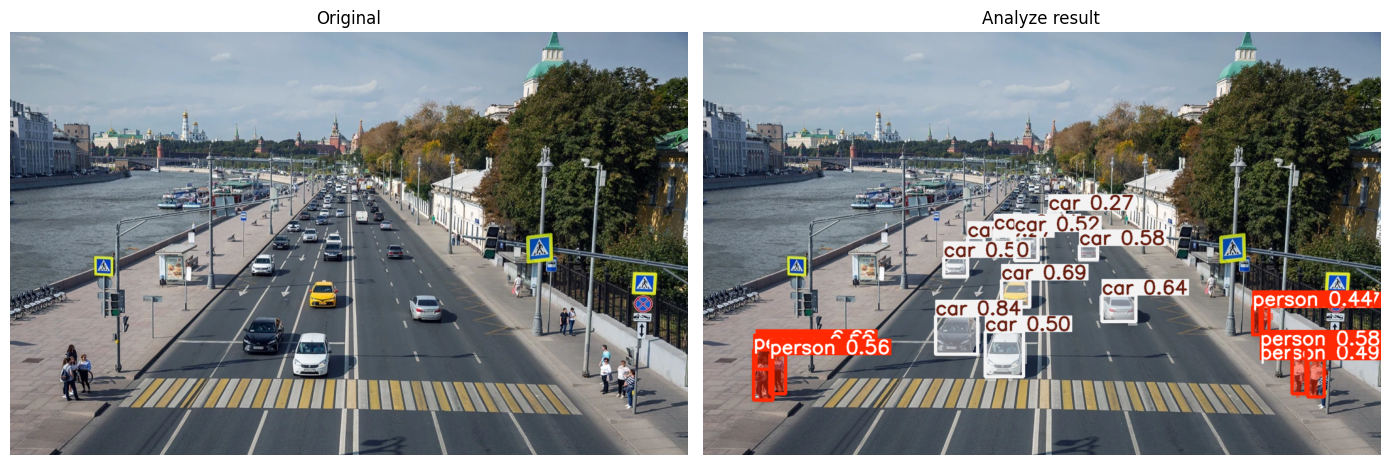

result size: (1080, 675) mode: RGB


In [8]:
result_img, payload, elapsed = call_analyze(IMAGE_PATH)
print("success:", payload.get("success"))
if not payload.get("success"):
    print("error:", payload.get("error"))
else:
    original = Image.open(IMAGE_PATH).convert("RGB")

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(result_img)
    plt.title("Analyze result")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("result size:", result_img.size, "mode:", result_img.mode)

In [ ]:
runs = 5
timings = []

for i in range(runs):
    print(f"run {i + 1}/{runs}")
    _, p, t = call_analyze(IMAGE_PATH)
    if not p.get("success"):
        print("stopping due to backend error:", p.get("error"))
        break
    timings.append(t)

if timings:
    warmup = timings[0]
    steady = timings[1:] if len(timings) > 1 else []

    print("\nLatency summary")
    print(f"all -> min={min(timings):.3f}s avg={sum(timings)/len(timings):.3f}s max={max(timings):.3f}s")
    print(f"warmup -> {warmup:.3f}s")

    if steady:
        print(f"steady -> min={min(steady):.3f}s avg={sum(steady)/len(steady):.3f}s max={max(steady):.3f}s")